In [1]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analyze_failure_modes(baseline_locations, cache_locations):
    """
    Generates diagnostic scatter plots to investigate caching failure modes.
    Analyzes: Baseline Time vs Speedup, Hit Rate vs Speedup, and Prev Evictions vs Speedup.
    """

    def parse_file(filepath, is_cache=False):
        records = []
        with open(filepath, 'r') as f:
            data = json.load(f)
            if not isinstance(data, list):
                data = [data]

            for item in data:
                # Basic identifiers
                record = {
                    'name': item.get('name'),
                    # Convert ID to int so we can sort sequences correctly
                    'id_int': int(item.get('id', 0)),
                    'template': item.get('sequenceElement', {}).get('template', 'unknown'),
                    'time': item.get('time')
                }

                # Extract cache-specific metrics (Adjust these keys to match your JSON)
                if is_cache:
                    cache_str = item.get("@comunica/persistent-cache-manager:sourceState")
                    if not cache_str:
                        cache_str = item.get("@comunica/persistent-cache-manager:sourceStateQuerySource")
                    is_error = True if item.get("error") else False
                    hit_rate = np.nan
                    if cache_str:
                        try:
                            cache_stats = json.loads(cache_str)
                            hits = cache_stats.get("hits", 0)
                            misses = cache_stats.get("misses", 0)
                            total = hits + misses
                            hit_rate = (hits / total) if total > 0 else 0.0
                        except json.JSONDecodeError:
                            print("ERROR")
                    if np.isnan(hit_rate):
                        raise ValueError("Nan hitrate")

                    record['hit_rate'] = hit_rate
                    record['evictions'] = item.get('evictions', 0)

                records.append(record)
        return pd.DataFrame(records)

    # 1. Process Baseline Data
    df_base_list = [parse_file(loc, is_cache=False) for loc in baseline_locations]
    df_base = pd.concat(df_base_list, ignore_index=True)
    df_base_agg = df_base.groupby(['name', 'id_int', 'template'])['time'].median().reset_index()
    df_base_agg.rename(columns={'time': 'time_baseline'}, inplace=True)

    # 2. Process Each Cache Strategy
    for cache_loc in cache_locations:
        strategy_label = os.path.basename(cache_loc).replace('.json', '')

        df_cache = parse_file(cache_loc, is_cache=True)
        # Aggregate median values for cache runs
        df_cache_agg = df_cache.groupby(['name', 'id_int', 'template']).agg({
            'time': 'median',
            'hit_rate': 'median',
            'evictions': 'median'
        }).reset_index()
        df_cache_agg.rename(columns={'time': 'time_cache'}, inplace=True)

        # Merge baseline and cache data
        merged = pd.merge(df_base_agg, df_cache_agg, on=['name', 'id_int', 'template'], how='inner')

        # Calculate Latency Speedup
        merged['speedup'] = merged['time_baseline'] / merged['time_cache']

        # Filter invalid log data
        merged = merged[merged['speedup'] > 0]

        # 3. Calculate "Previous Query Evictions"
        # Sort sequentially by sequence name and the integer ID
        merged.sort_values(by=['name', 'id_int'], inplace=True)

        # Shift the evictions column down by 1 within each specific sequence (name)
        merged['prev_evictions'] = merged.groupby('name')['evictions'].shift(1)

        # Fill NaN for the very first query in a sequence (which has no previous query)
        merged['prev_evictions'] = merged['prev_evictions'].fillna(0)

        # ==========================================
        # Render the 3-Panel Diagnostic Figure
        # ==========================================
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f'Failure Mode Diagnostics: {strategy_label}', fontsize=14, fontweight='bold')

        # Shared reference line for 1x speedup (Break-even point)
        for ax in axes:
            ax.axhline(1.0, color='red', linestyle='--', linewidth=1.5, zorder=1, label='Break-even (1x)')
            ax.set_yscale('log')
            ax.set_ylabel('Speedup Factor (Baseline / Cached)')
            ax.grid(True, which="both", linestyle="--", alpha=0.3)

        # Panel 1: Baseline Time vs. Speedup (Checking for Fixed Overhead)
        ax = axes[0]
        ax.scatter(merged['time_baseline'], merged['speedup'], alpha=0.5, color='#1f77b4', s=15)
        ax.set_xscale('log') # Log scale for baseline time is usually easier to read
        ax.set_xlabel('Baseline Execution Time (ms)')
        ax.set_title('1. Overhead check: Baseline Time vs Speedup')

        # Panel 2: Cache Hit Rate vs. Speedup (Checking Miss Penalty)
        ax = axes[1]
        ax.scatter(merged['hit_rate'], merged['speedup'], alpha=0.5, color='#ff7f0e', s=15)
        ax.set_xlabel('Cache Hit Rate')
        ax.set_title('2. Miss Penalty check: Hit Rate vs Speedup')

        # Panel 3: Previous Evictions vs. Speedup (Checking Thrashing Impact)
        ax = axes[2]
        ax.scatter(merged['prev_evictions'], merged['speedup'], alpha=0.5, color='#2ca02c', s=15)
        ax.set_xlabel('Evictions Triggered by PREVIOUS Query')
        ax.set_title('3. Thrashing check: Prev Evictions vs Speedup')

        plt.tight_layout()
        plt.show()

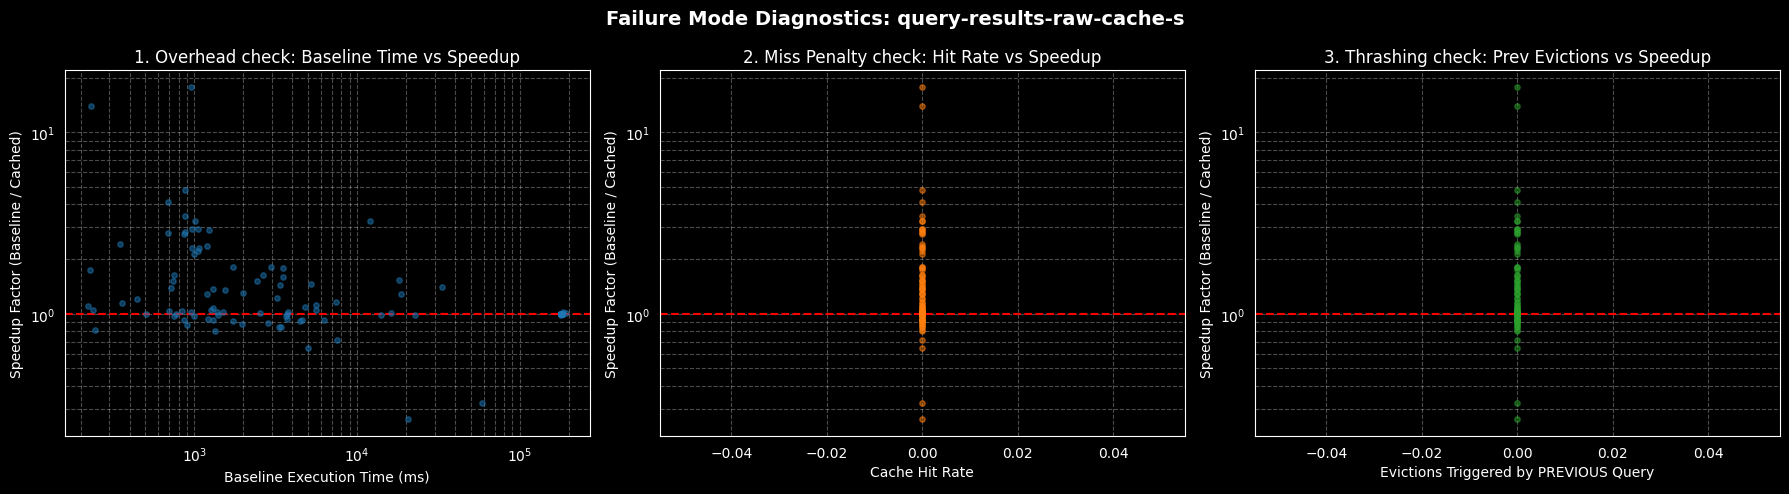

In [3]:
raw_data_cache_s = os.path.join("..", "data", "query-results-raw-cache-s.json")
raw_data_query_cache_s = os.path.join("..", "data", "query-results-raw-query-cache-s.json")
raw_data_query_cache_estimate_s = os.path.join("..", "data", "query-results-raw-query-cache-estimate-s.json")
raw_data_default = os.path.join("..", "data", "query-results-raw-default.json")
# all_locations_cache = [raw_data_cache_s, raw_data_query_cache_s, raw_data_query_cache_estimate_s]
# location_default = [ os.path.join("..", "data", "query-results-raw-default.json") ]

# uncached_files = ["/path/to/baseline_run1.json", "/path/to/baseline_run2.json"]
# cached_files = ["/path/to/cached_run1.json", "/path/to/cached_run2.json"]
# plot_speedup_from_locations(location_default, all_locations_cache, log_scale=False)
analyze_failure_modes([raw_data_default], [raw_data_cache_s])
# plot_speedup_from_locations(location_default, all_locations_cache)
# plot_speedup_from_locations(location_default, all_locations_cache)
